In [62]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from scipy.stats import skew, kurtosis
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.sandbox.stats.runs import runstest_1samp
from scipy import stats
warnings.filterwarnings('ignore')

In [2]:
sber = pd.read_csv(r'C:\Users\user\Desktop\AlgoTrading\data\RTS.txt')

In [3]:
# Преобразуем "сырой" датафрейм
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    
    """
  # 1. Делаем копию, чтобы не изменялся исходный датафрейм
  data = data.copy()
  
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['ticker', 'per', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """

    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'ticker': 'first',
            'per': 'first',
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    

    return_data['per'] = timeframe
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  result = result.reset_index()
  
  return result

In [4]:
sber_5 = good_dataframe(sber, '5 min')
sber_5.head()

,time,ticker,per,open,high,low,close,volume
0,2009-01-11 10:30:00,RTS,5 min,60480.0,64945.0,60480.0,62600.0,4611
1,2009-01-11 10:35:00,RTS,5 min,62565.0,62685.0,61905.0,62255.0,3604
2,2009-01-11 10:40:00,RTS,5 min,62260.0,62575.0,62020.0,62370.0,2072
3,2009-01-11 10:45:00,RTS,5 min,62325.0,62600.0,62275.0,62275.0,2494
4,2009-01-11 10:50:00,RTS,5 min,62275.0,62700.0,62250.0,62645.0,1188


In [5]:
# Преобразуем датафрейм для удобства работы с 2 свечными паттернами
def shift_features_2_candle(data):
    """Смещает все основные столбцы на 1 период назад

    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['time', 'ticker', 'per', 'open', 'high', 'low', 'close', 'volume']

    Returns:
        data (pd.DataFrame): Новый DataFrame с преобразованными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']
    """
    data_c = data.copy()
    for i in ['open', 'close', 'low', 'high', 'volume', 'time']:
        data_c[f"{i}_N"] = data[i]
        data_c[f'{i}_N-1'] = data[i].shift(1)
    data_c.drop(['open', 'close', 'low', 'high', 'volume', 'time'], axis=1, inplace=True)
    data_c.dropna(inplace=True)
    for i in ['open', 'close', 'low', 'high', 'volume']:
        data_c[f'{i}_N-1'] = data_c[f'{i}_N-1'].astype('int32')
    return data_c

sber_5s = shift_features_2_candle(sber_5)
sber_5s.head(3)

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1
1,RTS,5 min,62565.0,60480,62255.0,62600,61905.0,60480,62685.0,64945,3604,4611,2009-01-11 10:35:00,2009-01-11 10:30:00
2,RTS,5 min,62260.0,62565,62370.0,62255,62020.0,61905,62575.0,62685,2072,3604,2009-01-11 10:40:00,2009-01-11 10:35:00
3,RTS,5 min,62325.0,62260,62275.0,62370,62275.0,62020,62600.0,62575,2494,2072,2009-01-11 10:45:00,2009-01-11 10:40:00


In [6]:
# Размечаем датафрейм паттерном бычье поглощение
def detection_bullish_engulfing_pattern(data):
    """Функция для детекции бычьего паттерна поглощения

    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттетна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'bullish_engulfing_pattern'
        
    """

    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N_1 < close_N) & 
        (close_N_1 > open_N)
    )
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
    
    return data

sber_good = detection_bullish_engulfing_pattern(sber_5s)

In [7]:
sber_good.head(3)

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1,pattern,signal,strategy
1,RTS,5 min,62565.0,60480,62255.0,62600,61905.0,60480,62685.0,64945,3604,4611,2009-01-11 10:35:00,2009-01-11 10:30:00,0,0,bullish_engulfing_pattern
2,RTS,5 min,62260.0,62565,62370.0,62255,62020.0,61905,62575.0,62685,2072,3604,2009-01-11 10:40:00,2009-01-11 10:35:00,0,0,bullish_engulfing_pattern
3,RTS,5 min,62325.0,62260,62275.0,62370,62275.0,62020,62600.0,62575,2494,2072,2009-01-11 10:45:00,2009-01-11 10:40:00,0,0,bullish_engulfing_pattern


In [8]:
# Специальная функция для проверки эффективности паттернов 
def filter_min_distance(data, column, N):
    """Некоторые паттерны расположены слишком близко друг к другу, чтобы не было наложения сделок, 
    необходимо удалить все сигналы на покупку, которые появляются во время удержания позиции.
    Время удержания N периодов

    Args:
        data (pd.DataFrame): Преобразованный датафрейм
        'signal' (int64): Сигнальный столбец.
        N (int): Количество периодов, которые мы собираемся удерживать открытую позицию

    Returns:
        data (pd.DataFrame): Исходный датафрейм с отредактированным сигнальным столбцом
    """
    data = data.copy()
    # Получаем все индексы наблюдений где у нас есть сигнал на покупку
    one_index = data[data[column] == 1].index 
    # Получаем разность между этими индексами
    distances = np.diff(one_index)
    # Маска для каждого сигнала. Первый сигнал на покупку всегда True
    mask = [True]
    
    # Перебираем все разности между индексами
    for dist in distances:
        if dist >= N:
            # Если разность между индексами больше N, то все хорошо.
            # Мы добавляем эту сделку в список
            mask.append(True)
        else:
            # Если расстояние меньше, то сделку игнорируем
            mask.append(False)
            
    # Данные для удаления
    to_remove = one_index[np.where(~np.array(mask))[0]]
    data.loc[to_remove, column] = 0
    
    return data

In [9]:
# Готовим данные для дальнейшей проверки
def data_prepare_for_statistics(data, commision=0.0005):
    """Функция предназначена для обработки результатов стратегий.

    Args:
        data (pd.DataFrame): на вход подается размеченный датафрейм с колонкой 'signal'
        commision (float, optional): Размер комисии в долях процента (0.0005 ~ 0.05%). Defaults to 0.0005.

    Returns:
        list: Возвращаем список с датафреймами, каждый датафрейм это данные по каждой сделке (дата и размер прибыли в %)
    """
    data = data.copy()
    # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
    data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0
    
    # Проходимся циклом по периодам удержания позиции
    all_strategy = []
    for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
        data_h = filter_min_distance(data, 'signal', N) # Получаем фильтрованные данные
        data_h = data_h.set_index('time_N')
        # Блок для определения цены входа и выхода
        # То есть для каждой стратегии мы определяем вектора цен открытий и закрытий
        # Так как удерживаем позицию мы N периодов, то в качестве всех кандидатов, 
        # на которых мы можем закрыть позицию берем цены открытия через N периодов
        exit_candidate = data_h['open_N'].shift(-N) 
        is_entry = data_h['signal'] == 1
        entry_price = data_h['open_N'][is_entry]
        exit_price = exit_candidate[is_entry]
        
        # Считаем результат
        profit_percent = pd.Series(np.round((exit_price.values - entry_price.values) / entry_price.values, 5), index=entry_price.index,
                                   name='profit_percent')# % доход за сделку
        percent_profit_net = profit_percent - commision
        percent_profit_without_commission = profit_percent
        
        strategy_data = pd.DataFrame({'profit_percent_net' : np.array(percent_profit_net), 
                                      'percent_profit_without_commission' : np.array(percent_profit_without_commission),
                                       'N' : N, 
                                       'strategy_name' : data_h['strategy'].iloc[0],
                                       'ticker' : data_h['ticker'].iloc[0],
                                       'period' : data_h['per'].iloc[0]},
                            index=profit_percent.index)
        all_strategy.append(strategy_data)
        
    return all_strategy
        

In [10]:
sber_prepared = data_prepare_for_statistics(sber_good)

In [11]:
# Функция для получения результатов стратегии
def trade_statistics_bull(all_strategy_data):
    """Функция предназначена для агрегирования результатов стратегий по основным финансовым метрикам

    Args:
        all_strategy_data (list): Подаётся список с датафреймами, где для для каждой сделки установлено время и размер прибыли в %.

    Returns:
        data (pd.DataFrame): Возвращаем новый датафрейм со всеми необходимыми метриками для оценки стратегий.
    """
    capital = 100_000
    strategies = []
    for strategy in all_strategy_data:
        
        # Считаем основные метрики
        ticker = strategy['ticker'].iloc[0]
        strategy_name = strategy['strategy_name'].iloc[0]
        period = strategy['period'].iloc[0]
        N = strategy['N'].iloc[0]
        count_of_trades = len(np.array(strategy['profit_percent_net']))
        profit_percent_net = strategy['profit_percent_net']
        percent_profit_without_commission = strategy['percent_profit_without_commission']
        
        # Кривая капитала 
        capital_curve_net = capital * np.cumprod(1 + strategy['profit_percent_net'])
        capital_curve_without_commission = capital * np.cumprod(1 + strategy['percent_profit_without_commission'])
        
        # Профит фактор
        pr_per_net = np.array(strategy['profit_percent_net'])
        profit_factor = np.round(np.sum(pr_per_net[pr_per_net > 0]) / np.abs(np.sum(pr_per_net[pr_per_net < 0])), 3)
        
        # Общий % доход !!!
        total_per_return_r = np.array(np.cumprod(1 + strategy['profit_percent_net']))[-1]
        total_per_return = np.round((total_per_return_r - 1) * 100, 2)
        
        # Win_rate 
        win_rate = np.round(np.mean(pr_per_net > 0), 2)
        
        # R2
        X = np.array(list(range(len(capital_curve_net)))).reshape(-1, 1)
        y = np.array(capital_curve_net)
        lin = LinearRegression()
        lin.fit(X, y)
        y_pred = lin.predict(X)
        beta = np.round(lin.coef_[-1], 2)
        r2 = np.round(metrics.r2_score(y, y_pred), 2)
        
        strategies.append({
          'ticker' : ticker,
          'strategy name' : strategy_name,
          'period' : period,
          'N' : N,
          'count of trades' : count_of_trades,
          'profit factor' : profit_factor,
          'total percent return' : total_per_return,
          'R2' : r2,
          'beta' : beta,
          'win_rate' : win_rate,
          'capital curve net' : capital_curve_net,
          'capital curve without commission' : capital_curve_without_commission,
          'profit percent net' : profit_percent_net,
          'percent profit without commission' : percent_profit_without_commission}
          )
        
    return pd.DataFrame(strategies)

result = trade_statistics_bull(sber_prepared)

In [12]:
# Проверяем стратегии на множестве ТФ.
def backtest_strategies_multi_tf(data):
    """Функция позволяет проверить эффективность стратегии бычье поглощение на 7 основных таймфреймах.
    На выходе получаем большую сводную таблицу по результатам стратегии на всех таймфреймах.

    Args:
        data (pd.DataFrame): Подаем датафрейм с 1 минутным таймфреймом

    Returns:
        data (pd.DataFrame): Таблица с результатами всех стратегий
    """
    data = data.copy()
    l = []
    # Перебираем все тф
    for i in ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']:
        data_tm = good_dataframe(data, i)
        l.append(data_tm)
    
    all_strategy = []
    # Для каждого тф проверяем стратегию бычье поглощение
    for j in l:
        detection_data = detection_bullish_engulfing_pattern(shift_features_2_candle(j))
        result = data_prepare_for_statistics(detection_data)
        final_result = trade_statistics_bull(result)
        all_strategy.append(final_result)
    # Объединяем результат   
    combined_data = pd.concat(all_strategy, ignore_index=True)
    
    return combined_data

sber_result_strategies = backtest_strategies_multi_tf(sber)
sber_result_strategies.head(3)

,ticker,strategy name,period,N,count of trades,profit factor,total percent return,R2,beta,win_rate,capital curve net,capital curve without commission,profit percent net,percent profit without commission
0,RTS,bullish_engulfing_pattern,5 min,1,18638,0.406,-99.99,0.52,-2.78,0.28,time_N 2009-01-11 12:10:00 99926.000000 200...,time_N 2009-01-11 12:10:00 99976.000000 20...,time_N 2009-01-11 12:10:00 -0.00074 2009-01-...,time_N 2009-01-11 12:10:00 -0.00024 2009-01-...
1,RTS,bullish_engulfing_pattern,5 min,2,18638,0.503,-99.99,0.49,-2.62,0.33,time_N 2009-01-11 12:10:00 99756.000000 200...,time_N 2009-01-11 12:10:00 99806.000000 200...,time_N 2009-01-11 12:10:00 -0.00244 2009-01-...,time_N 2009-01-11 12:10:00 -0.00194 2009-01-...
2,RTS,bullish_engulfing_pattern,5 min,3,18085,0.562,-99.99,0.52,-2.95,0.35,time_N 2009-01-11 12:10:00 99772.000000 200...,time_N 2009-01-11 12:10:00 99822.000000 200...,time_N 2009-01-11 12:10:00 -0.00228 2009-01-...,time_N 2009-01-11 12:10:00 -0.00178 2009-01-...


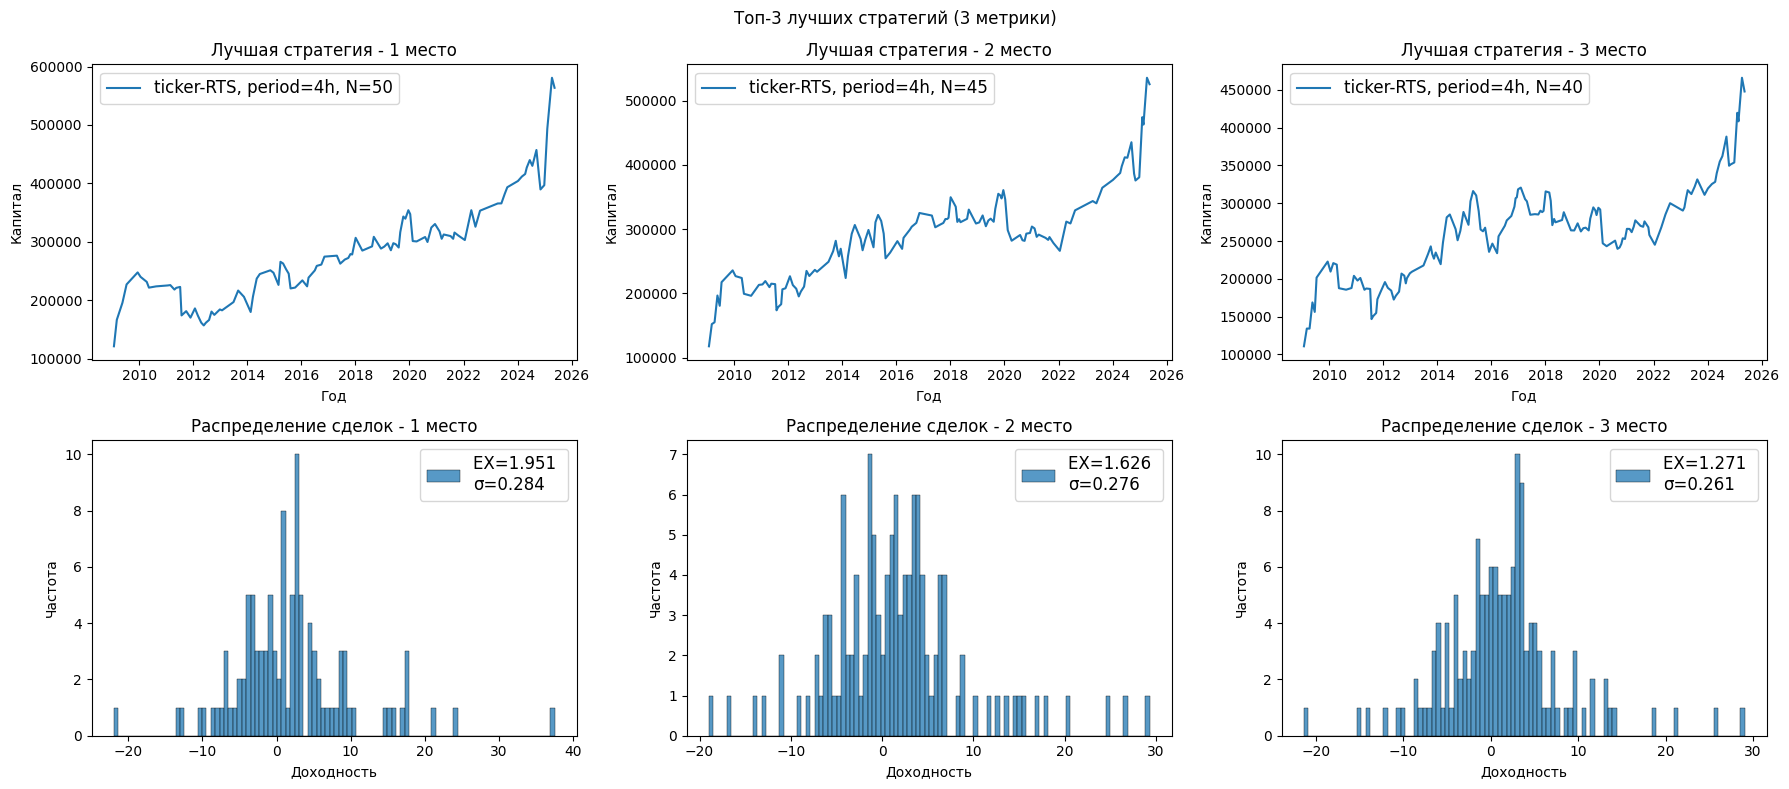

,ticker,strategy name,period,N,count of trades,profit factor,total percent return,R2,beta,win_rate
0,RTS,bullish_engulfing_pattern,4h,50,106,2.032,463.64,0.79,2501.85,0.59
1,RTS,bullish_engulfing_pattern,4h,45,124,1.838,425.63,0.73,1689.63,0.58
2,RTS,bullish_engulfing_pattern,4h,40,144,1.706,347.94,0.65,1168.73,0.58
3,RTS,bullish_engulfing_pattern,D,6,144,1.661,202.60,0.69,984.87,0.60
4,RTS,bullish_engulfing_pattern,D,5,150,1.573,144.80,0.66,669.19,0.55
5,RTS,bullish_engulfing_pattern,2h,40,251,1.366,163.72,0.60,558.94,0.56
6,RTS,bullish_engulfing_pattern,D,7,139,1.473,129.82,0.53,571.51,0.59
7,RTS,bullish_engulfing_pattern,D,9,124,1.427,113.87,0.60,689.25,0.55
8,RTS,bullish_engulfing_pattern,4h,35,175,1.406,154.56,0.41,312.68,0.56
9,RTS,bullish_engulfing_pattern,D,10,119,1.396,98.62,0.62,976.86,0.56


In [13]:
# Функция для первичного отбора стратегий
def compare_strategies(data):
    """Функция предназначена для сравнения полученных стратегий и выявления наилучших претендентов
    для дальнейшего анализа.

    Args:
        data (pd.DataFrame): Датафрейм с результатами стратегий
    Returns:
        data (pd.DaraFrame): Возвращаем отфильтрованный датафрейм со результатами стратегии на всех тайфреймах.
    """
    # Фильтрация стратегий
    data = data[(data['count of trades'] > 100) & (data['profit factor'] > 1) & (data['total percent return'] > 0) & (data['beta'] > 0)] # Ограничение по количеству сделок
    
    data['profit factor rank'] = data['profit factor'].rank() # Больше лучше
    data['R2 rank'] = data['R2'].rank() # Больше лучше
    data['total percent return rank'] = data['total percent return'].rank() # Больше лучше
    data['best model'] = data['profit factor rank'] + data['R2 rank'] + data['total percent return rank']
    
    # Построение графиков 3 лучших стратегий
    
    data.sort_values('best model', ascending=False, inplace=True, ignore_index=True)
        
    # График
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    plt.suptitle('Топ-3 лучших стратегий (3 метрики)')
        
    # Первые 3 графика
    sns.lineplot(data.loc[0, 'capital curve net'], ax=axes[0, 0], label=f'ticker-{data.loc[0, 'ticker']}, period={data.loc[0, 'period']}, N={data.loc[0, 'N']}');
    sns.lineplot(data.loc[1, 'capital curve net'], ax=axes[0, 1], label=f'ticker-{data.loc[1, 'ticker']}, period={data.loc[1, 'period']}, N={data.loc[1, 'N']}');
    sns.lineplot(data.loc[2, 'capital curve net'], ax=axes[0, 2], label=f'ticker-{data.loc[2, 'ticker']}, period={data.loc[2, 'period']}, N={data.loc[2, 'N']}');
    axes[0, 0].legend(fontsize=12)
    axes[0, 1].legend(fontsize=12)
    axes[0, 2].legend(fontsize=12)
    
    axes[0, 0].set_title('Лучшая стратегия - 1 место')
    axes[0, 1].set_title('Лучшая стратегия - 2 место')
    axes[0, 2].set_title('Лучшая стратегия - 3 место')
    axes[0, 0].set_ylabel('Капитал')
    axes[0, 1].set_ylabel('Капитал')
    axes[0, 2].set_ylabel('Капитал')
    axes[0, 0].set_xlabel('Год')
    axes[0, 1].set_xlabel('Год')
    axes[0, 2].set_xlabel('Год')
        
    # Вторые 3 графика
    sns.histplot(data.loc[0, 'profit percent net'] * 100, ax=axes[1, 0], bins=100, 
                     label=f'EX={np.round(np.mean(data.loc[0, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit percent net"])),3)}');
    sns.histplot(data.loc[1, 'profit percent net'] * 100, ax=axes[1, 1], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[1, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit percent net"])),3)}');
    sns.histplot(data.loc[2, 'profit percent net'] * 100, ax=axes[1, 2], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[2, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit percent net"])),3)}');
    axes[1, 0].legend(fontsize=12)
    axes[1, 1].legend(fontsize=12)
    axes[1, 2].legend(fontsize=12)
        
    axes[1, 0].set_title('Распределение сделок - 1 место')
    axes[1, 1].set_title('Распределение сделок - 2 место')
    axes[1, 2].set_title('Распределение сделок - 3 место')
    axes[1, 0].set_ylabel('Частота')
    axes[1, 1].set_ylabel('Частота')
    axes[1, 2].set_ylabel('Частота')
    axes[1, 0].set_xlabel('Доходность')
    axes[1, 1].set_xlabel('Доходность')
    axes[1, 2].set_xlabel('Доходность')
        
    plt.tight_layout()
    plt.show()
    data_new = data[['ticker', 'strategy name', 'period', 'N', 'count of trades',
       'profit factor', 'total percent return', 'R2', 'beta', 'win_rate']]
        
    display(data_new)
                
    return data
    
res = compare_strategies(sber_result_strategies)

2. Метрики последовательности сделок (очень важно для паттернов!)
• Автокорреляция (Lag-1, Lag-2, Lag-3) - зависит ли результат текущей сделки от предыдущих
• Длины серий побед/поражений (Run Tests) - максимальная и средняя длина серий
• Переходные вероятности - вероятность выигрыша после выигрыша, после проигрыша и т.д.
• Тест Вальда-Вольфовица (Wald-Wolfowitz runs test) - проверяет, случайна ли последовательность знаков (+/-)
• Тест Бокса-Пирса (Ljung-Box test) - проверяет наличие автокорреляции в целом


In [14]:
def run_analysis(lst):
    """_summary_

    Args:
        lst (_type_): _description_

    Returns:
        _type_: _description_
    """
    lst_new = np.array(lst)
    lst_sign = (lst_new > 0).astype(int)
    n_win = np.sum(lst_sign) # Количество прибыльных сделок
    n_loss = len(lst_sign) - n_win # Количество убыточных сделок
    win_rate = np.round(n_win / len(lst_sign) * 100)
    
    # Считаем количество серий
    count_series = 1
    for i in range(1, len(lst_sign)):
        if lst_sign[i-1] != lst_sign[i]:
            count_series += 1
            
    # Считаем максимальное количество подряд идущих прибыльных сделок и среднюю серию прибыльных сделок
    list_win = []
    count_win = 0
    for i in range(len(lst_sign)):
        if lst_sign[i] == 1:
            count_win += 1
        else:
            if count_win != 0:
                list_win.append(count_win)
            count_win = 0
    if count_win > 0:
        list_win.append(count_win) 
    
    mean_wins_series = np.round(np.mean(list_win), 1)
    max_wins_series = np.max(list_win)     
    
    # Считаем максимальное количество подряд идущих убыточных сделок и среднюю серию убыточных сделок
    list_loss = []
    count_loss = 0
    for i in range(1, len(lst_sign)):
        if lst_sign[i] == 0:
            count_loss += 1
        else:
            if count_loss != 0:
                list_loss.append(count_loss)
            count_loss = 0
    if count_loss > 0:
        list_loss.append(count_loss)
    
    mean_loss_series = np.round(np.mean(list_loss), 1)
    max_loss_series = np.max(list_loss)
    
    
    # Проводим тест Вальда-Вольфовица для определения случайности в сериях сделок
    z_stat, p_value = runstest_1samp(lst_sign, correction=False)
    if p_value < 0.05:
        p_val_result = 'Да, паттерн неслучаен'
        if z_stat < 0:
            z_stat_result = 'Наблюдается кластеризация, серии длиннее случайных'
        else:
            z_stat_result = 'Частое чередование (серии короче случайных)'
    else:
        p_val_result = 'Нет'
        
    # Условные вероятности
    df_usl = pd.DataFrame({'current' : lst_sign})
    df_usl['previous'] = df_usl['current'].shift(1)
    df_usl.dropna(inplace=True)
    Crosstable = np.round(pd.crosstab(columns=df_usl['current'], index=df_usl['previous'], normalize='index'), 2)
    
    final_data = pd.Series({'Total Trades' : len(lst_sign),
                            'Win Rate (%)' : win_rate,
                            'count of series' : count_series,
                            'Winning Trades' : n_win,
                            'Lossing Trades' : n_loss,
                            'Avg. Win Streak' : mean_wins_series,
                            'Max Win Streak' : max_wins_series,
                            'Avg. Loss Streak' : mean_loss_series,
                            'Max Loss Streak' : max_loss_series}).reset_index()
    # Результат теста Вальда-Вольфовица
    final_df = pd.Series({'Стат. знач. паттерн' : p_val_result, 
                    'Анализ серий' : (z_stat_result if p_value < 0.05 else ''),
                    'P(Win after Win)' : Crosstable.iloc[1,1],
                    'P(Win after Loss)' : Crosstable.iloc[0, 1],
                    'P(Loss after Loss)' : Crosstable.iloc[0, 0],
                    'P(Loss after Win)' : Crosstable.iloc[1, 0]}, name='Теста Вальда-Вольфовица').reset_index()
    
    data = pd.concat([final_data, final_df], axis=1, ignore_index=True).fillna('').rename(columns={0 : 'Основные метрики', 
                                                                                                   1 : 'Значение', 
                                                                                                   2 : 'Тест Вальда-Вольфовица',
                                                                                                   3 : 'Результат'})
    return data


ac = run_analysis(res.loc[0, 'profit percent net'])
ac

,Основные метрики,Значение,Тест Вальда-Вольфовица,Результат
0,Total Trades,106.0,Стат. знач. паттерн,Нет
1,Win Rate (%),59.0,Анализ серий,
2,count of series,54.0,P(Win after Win),0.57
3,Winning Trades,63.0,P(Win after Loss),0.62
4,Lossing Trades,43.0,P(Loss after Loss),0.38
5,Avg. Win Streak,2.3,P(Loss after Win),0.43
6,Max Win Streak,10.0,,
7,Avg. Loss Streak,1.6,,
8,Max Loss Streak,4.0,,


Тест Андерсона-Дарлинга:
Статистика 2.115
15.0%: 0.557 - Распределение НЕ нормальное
10.0%: 0.626 - Распределение НЕ нормальное
5.0%: 0.747 - Распределение НЕ нормальное
2.5%: 0.867 - Распределение НЕ нормальное
1.0%: 1.028 - Распределение НЕ нормальное
Данные Не нормальные
0.038231069952788764


,Показатель,Значение,p-значение,Наличие автокорреляции
1,Максимальная прибыль (%),37.48,0.028,Да (p ≤ 0.05)
2,99-й перцентиль (%),24.20,0.077,Нет (p > 0.05)
3,95-й перцентиль (%),17.33,0.148,Нет (p > 0.05)
4,75-й перцентиль (%),5.00,0.189,Нет (p > 0.05)
5,Медиана (50%) (%),1.10,0.293,Нет (p > 0.05)
6,25-й перцентиль (%),-2.90,0.309,Нет (p > 0.05)
7,5-й перцентиль (%),-8.34,0.284,Нет (p > 0.05)
8,1-й перцентиль (%),-13.24,0.349,Нет (p > 0.05)
9,Максимальный убыток (%),-21.92,0.444,Нет (p > 0.05)
10,Коэффициент асимметрии,1.01,0.539,Нет (p > 0.05)


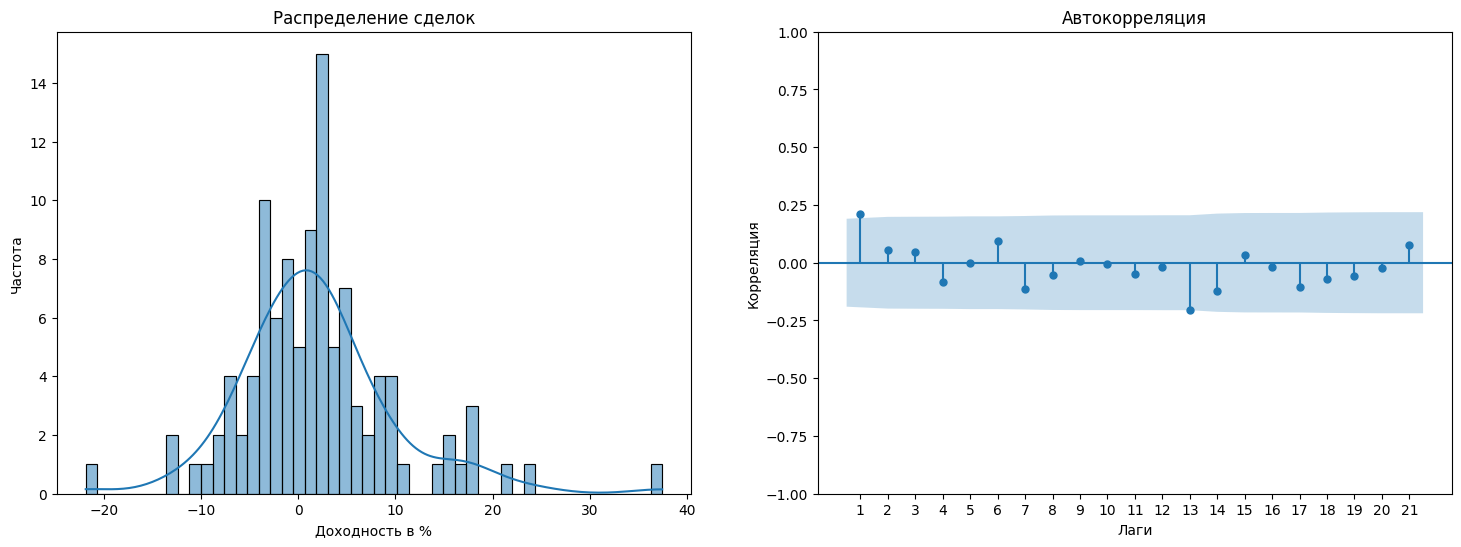

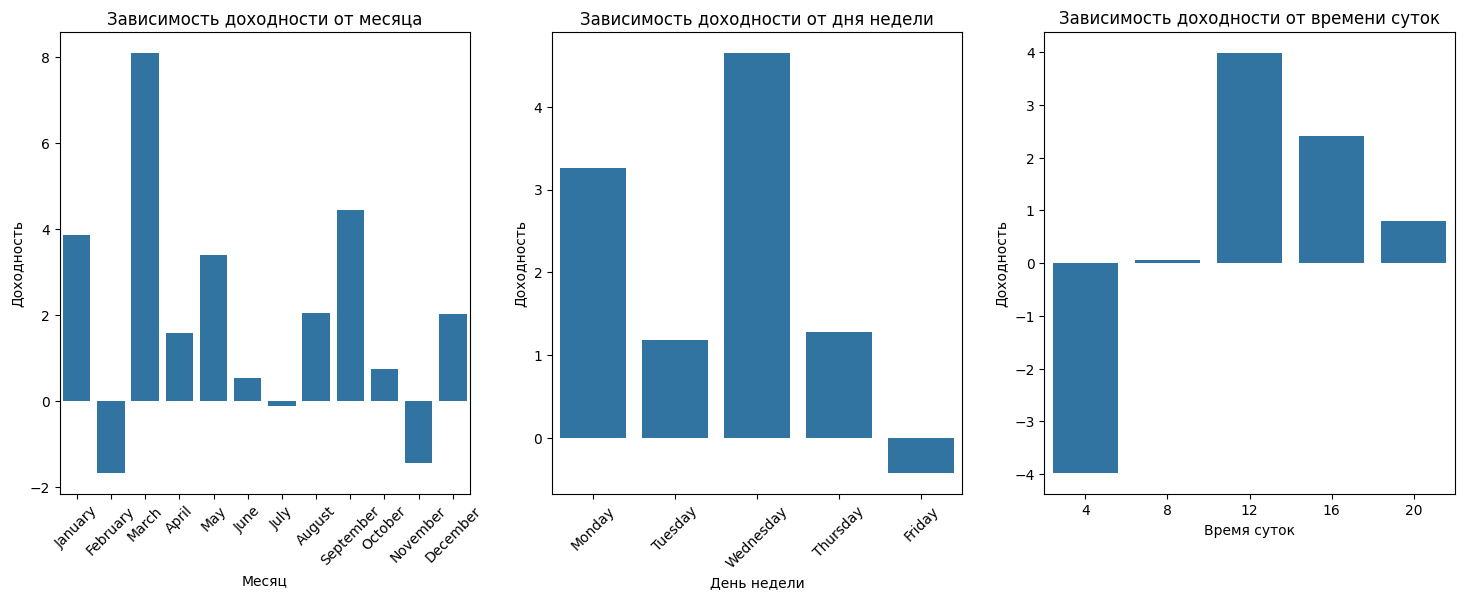

In [77]:
# Функция для глубокого статистического анализа паттернов
def deep_statistics(data, indx, deep_analyze=1):
    pr_percent_net = data.loc[indx, 'profit percent net']
    
    # 1. Метрики распределения доходностей
    Skewness = skew(pr_percent_net)
    Kurtosis = kurtosis(pr_percent_net, fisher=True)
    MIN = np.min(pr_percent_net)
    q_1 = np.quantile(pr_percent_net, 0.01)
    q_5 = np.quantile(pr_percent_net, 0.05)
    q_25 = np.quantile(pr_percent_net, 0.25)
    q_50 = np.quantile(pr_percent_net, 0.5)
    q_75 = np.quantile(pr_percent_net, 0.75)
    q_95 = np.quantile(pr_percent_net, 0.95)
    q_99 = np.quantile(pr_percent_net, 0.99)
    MAX = np.max(pr_percent_net)
    
    # График 1
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.histplot(pr_percent_net * 100, ax=axes[0], bins=50, kde=True)
    axes[0].set_title('Распределение сделок')
    axes[0].set_xlabel('Доходность в %')
    axes[0].set_ylabel('Частота')
    plot_acf(pr_percent_net, zero=False, ax=axes[1])
    axes[1].set_title('Автокорреляция')
    axes[1].set_xlabel('Лаги')
    axes[1].set_ylabel('Корреляция')
    axes[1].set_xticks(range(1, 22))
    
    # 1. Статистика распределения сделок
    dist_data = pd.Series({
    'Максимальная прибыль (%)': np.round(MAX * 100, 2),
    '99-й перцентиль (%)': np.round(q_99 * 100, 2),
    '95-й перцентиль (%)': np.round(q_95 * 100, 2),
    '75-й перцентиль (%)': np.round(q_75 * 100, 2),
    'Медиана (50%) (%)': np.round(q_50 * 100, 2),
    '25-й перцентиль (%)': np.round(q_25 * 100, 2),
    '5-й перцентиль (%)': np.round(q_5 * 100, 2),
    '1-й перцентиль (%)': np.round(q_1 * 100, 2),
    'Максимальный убыток (%)': np.round(MIN * 100, 2),
    'Коэффициент асимметрии': np.round(Skewness, 3),
    'Коэффициент эксцесса': np.round(Kurtosis, 3)
    }).reset_index()
    dist_data.columns = ['Показатель', 'Значение']
    dist_data.index = range(1, len(dist_data) + 1)

    # 2. Тест Льюнга-Бокса
    lb_test = acorr_ljungbox(pr_percent_net, lags=np.arange(1, 13))
    lb_data = pd.DataFrame({
    'p-значение': np.round(lb_test['lb_pvalue'], 3),
    'Наличие автокорреляции': lb_test['lb_pvalue'].apply(
        lambda x: 'Да (p ≤ 0.05)' if x <= 0.05 else 'Нет (p > 0.05)')})

    lb_data_reindexed = lb_data.reindex(dist_data.index).fillna('')
    result = pd.concat([dist_data, lb_data_reindexed], axis=1)
    
    # 3. Анализ временных факторов
    data_percent = (pr_percent_net * 100).to_frame().reset_index()
    data_percent['time_N'] = pd.to_datetime(data_percent['time_N'])
    data_percent['Month'] = data_percent['time_N'].dt.month_name()
    data_percent['day_of_week'] = data_percent['time_N'].dt.day_name()
    data_percent['hour'] = data_percent['time_N'].dt.hour
    # Группировка
    months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']
    weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    data_percent_group_month = data_percent.groupby('Month')['profit_percent_net'].mean().reset_index()
    data_percent_group_day_of_week = data_percent.groupby('day_of_week')['profit_percent_net'].mean().reset_index()
    data_percent_group_hour = data_percent.groupby('hour')['profit_percent_net'].mean().reset_index()
    # График 2
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    # 1
    sns.barplot(data_percent_group_month, x=data_percent_group_month['Month'], y=data_percent_group_month['profit_percent_net'], ax=axes[0],
                order=months)
    axes[0].set_title('Зависимость доходности от месяца')
    axes[0].set_xlabel('Месяц')
    axes[0].set_ylabel('Доходность')
    axes[0].set_xticklabels(labels=months, rotation=45)
    # 2
    sns.barplot(data_percent_group_day_of_week, x=data_percent_group_day_of_week['day_of_week'], y=data_percent_group_day_of_week['profit_percent_net'], ax=axes[1],
                order=weekdays)
    axes[1].set_title('Зависимость доходности от дня недели')
    axes[1].set_xlabel('День недели')
    axes[1].set_ylabel('Доходность')
    axes[1].set_xticklabels(labels=weekdays, rotation=45)
    # 3
    sns.barplot(data_percent_group_hour, x=data_percent_group_hour['hour'], y=data_percent_group_hour['profit_percent_net'], ax=axes[2])
    axes[2].set_title('Зависимость доходности от времени суток')
    axes[2].set_xlabel('Время суток')
    axes[2].set_ylabel('Доходность')
    
    # 4. Тесты на нормальность и случайность
    print('Тест Андерсона-Дарлинга:')
    Anderson_test = stats.anderson(pr_percent_net, dist='norm')
    print(f'Статистика {np.round(Anderson_test.statistic, 3)}')
    for i in range(len(Anderson_test.critical_values)):
        sl, cv = Anderson_test.significance_level[i], Anderson_test.critical_values[i]
        print(f"{sl}%: {cv} - {'Нормальное распределение' if Anderson_test.statistic < cv else 'Распределение НЕ нормальное'}")
        
    if Anderson_test.significance_level[2] > Anderson_test.statistic:
        print('Данные Не нормальные')
        Wilcoxon = stats.wilcoxon(pr_percent_net, 0)
        print(Wilcoxon.pvalue)
    display(result)
result_statistics = deep_statistics(res, 0)

In [63]:
from scipy import stats

# Те же данные
data = [1.2, 1.8, 2.1, 1.5, 1.9, 2.3, 1.7, 2.0, 1.6, 1.4]

# Тест Андерсона-Дарлинга
result = stats.anderson(data, dist='norm')

print(f"Статистика: {result.statistic:.4f}")
print("Критические значения:")
for i in range(len(result.critical_values)):
    sl, cv = result.significance_level[i], result.critical_values[i]
    print(f"  {sl}%: {cv:.4f} - {'Нормально' if result.statistic < cv else 'Не нормально'}")

Статистика: 0.0862
Критические значения:
  15.0%: 0.5110 - Нормально
  10.0%: 0.5750 - Нормально
  5.0%: 0.6850 - Нормально
  2.5%: 0.7950 - Нормально
  1.0%: 0.9430 - Нормально


1. Написать функцию для глубокой статистической проверки лучших стратегий

Результат: осталось совсем немного, статистические тесты, да пару метрик, ну может ещё чего-то.
Может быть стоит разбить это на 2 функции и не мучить себя огромными текстами.

2. Надо сделать 5 до паттернов, чтобы у нас добавилось данных

3. Переход к ML
3.1 Вопросы про одноклассовость и многоклассовость
3.2 Создание признаков
3.3 Проверка признаков на стационарность

4. Создание модели ML.